In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import h5py

import chroma

plt.style.use("chroma.paper")

In [2]:
msd = {}
with h5py.File(
    "/scratch/mm146/Polarization/3_IMR-90_hg38_fields-nb/4_analysis/msd/data/msd-average-per-compartment.h5",
    "r",
) as f_in:
    for condition in f_in.keys():
        msd[condition] = {}
        for compartment in f_in[condition].keys():
            msd[condition][compartment] = f_in[condition][
                compartment
            ][()]

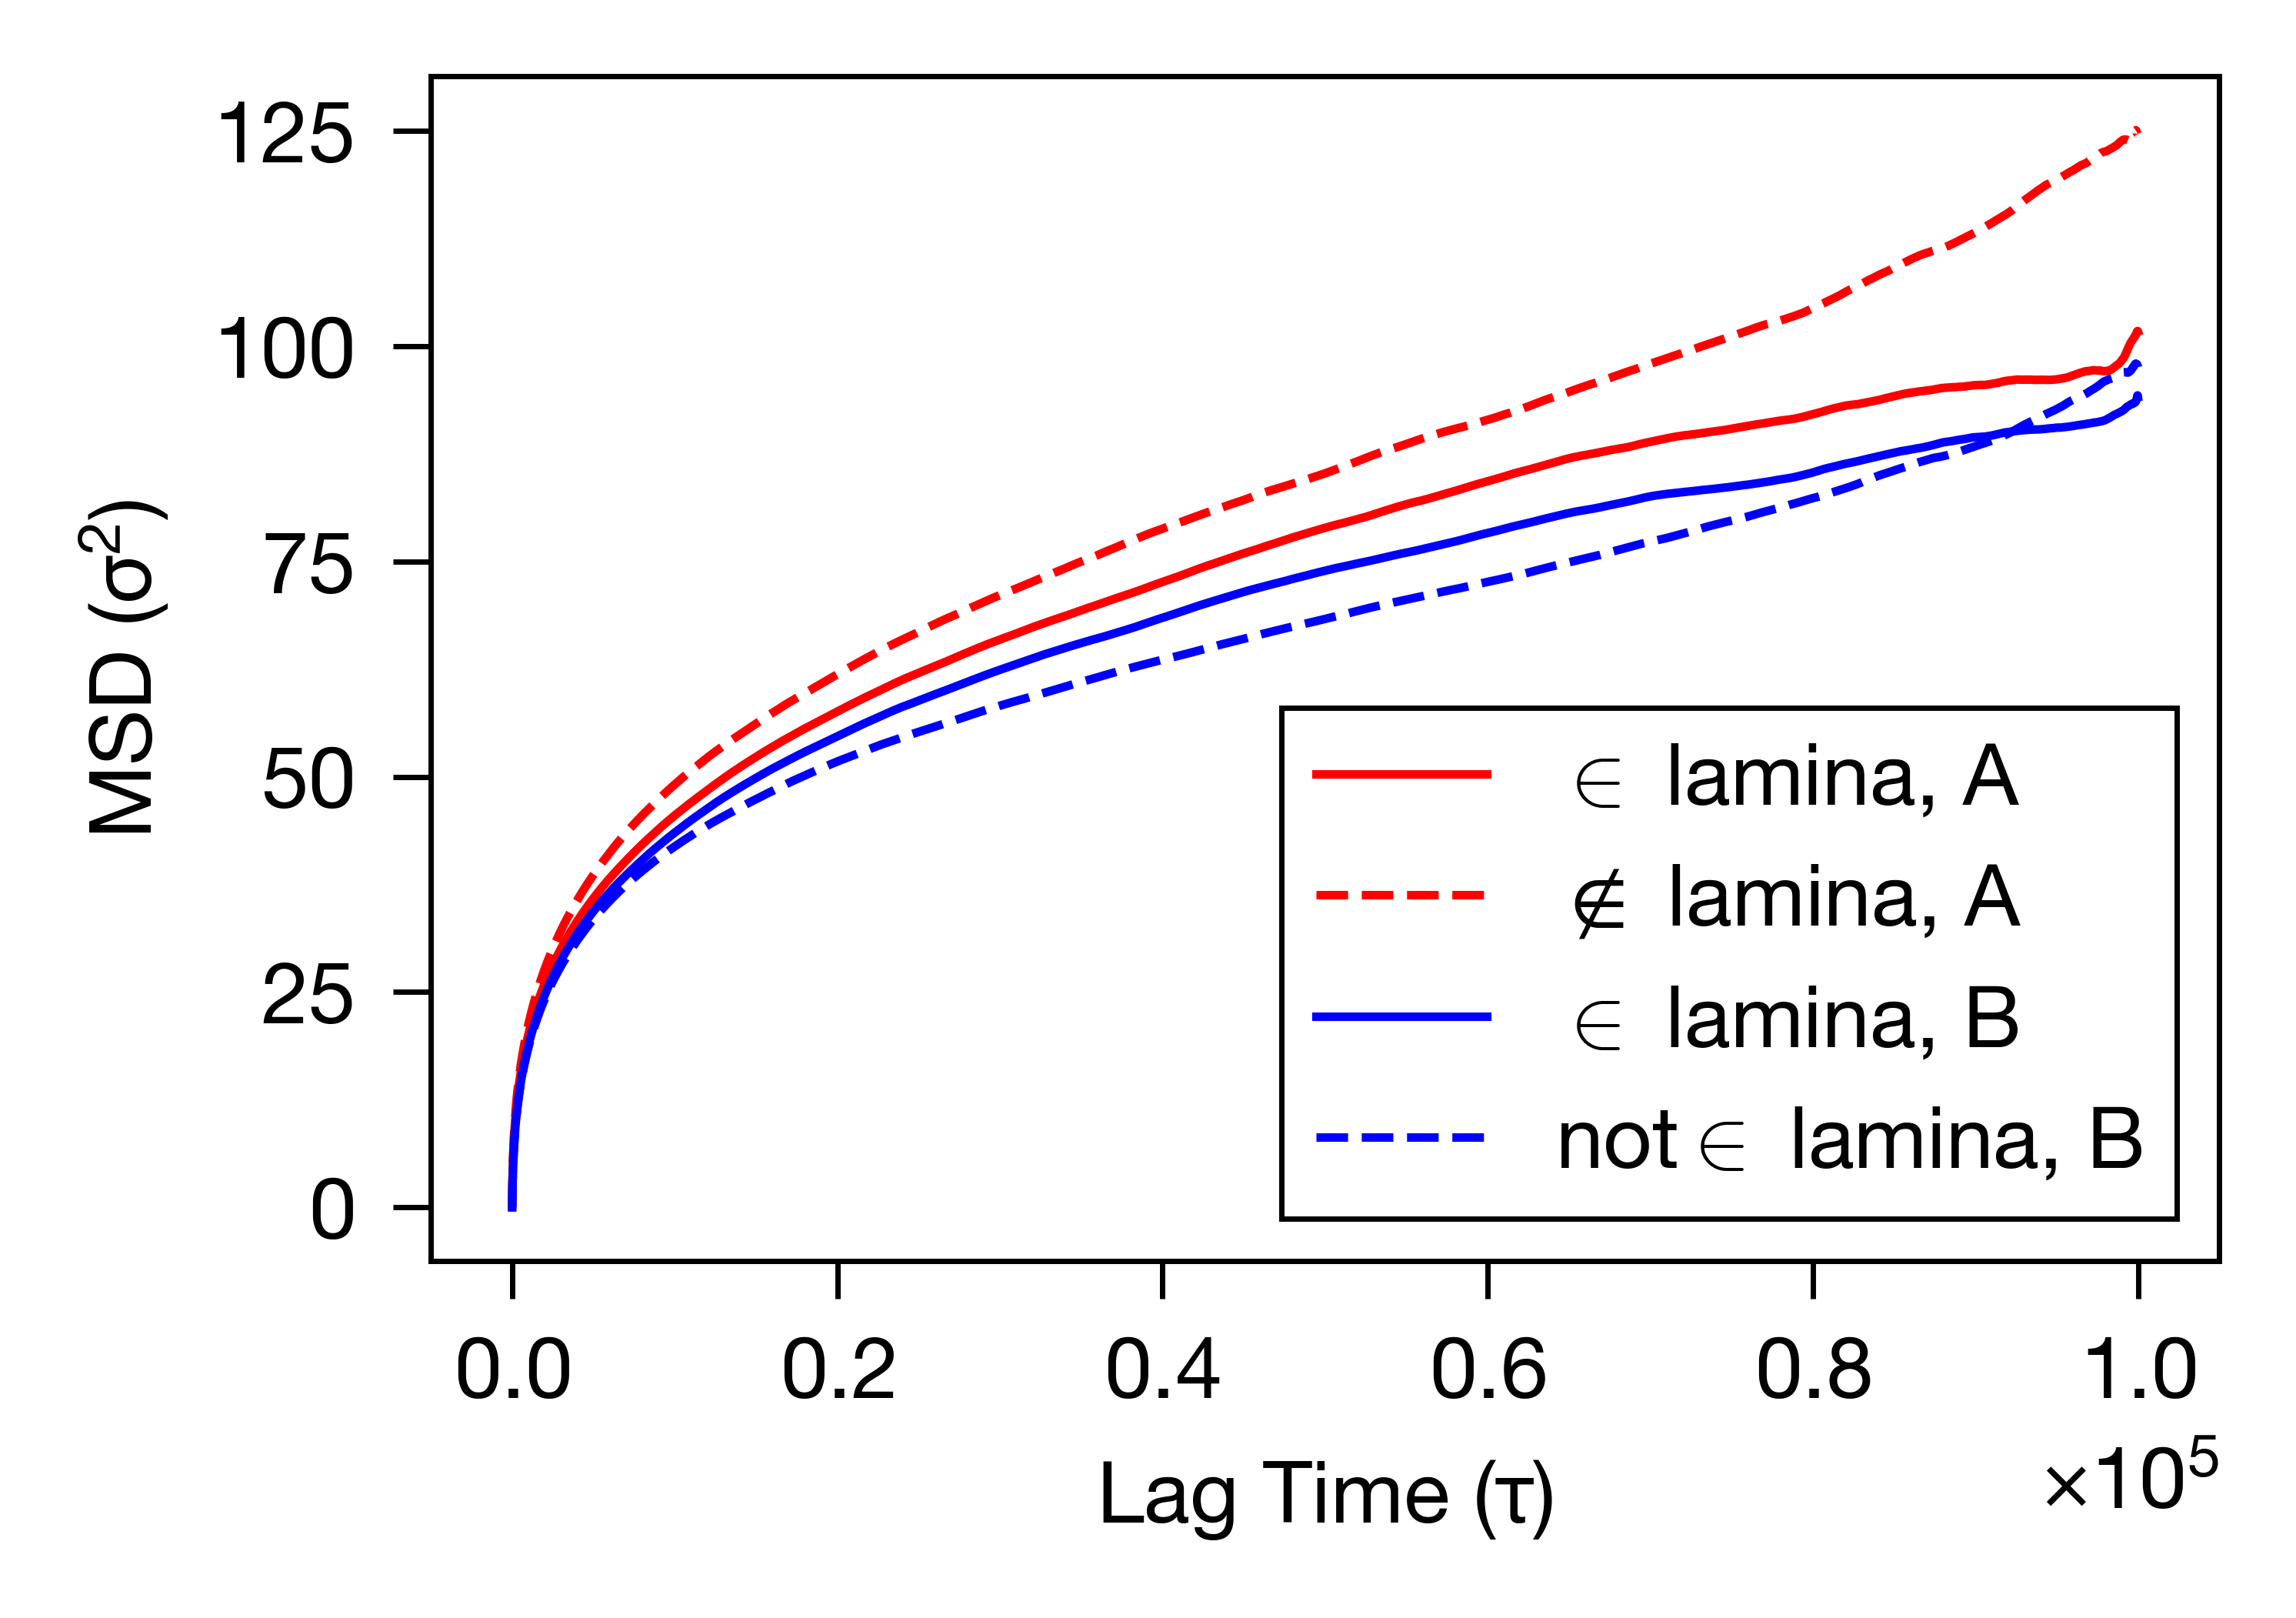

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.plot(
    lag,
    msd["complete"]["A"],
    label=r"$\in$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["nucleolus"]["A"],
    "--",
    label=r"$\notin$ lamina, A",
    color="red",
)
ax.plot(
    lag,
    msd["complete"]["B"],
    label=r"$\in$ lamina, B",
    color="blue",
)
ax.plot(
    lag,
    msd["nucleolus"]["B"],
    "--",
    label=r"$not\in$ lamina, B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

ax.legend()

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation
ax.xaxis.set_major_formatter(formatter)

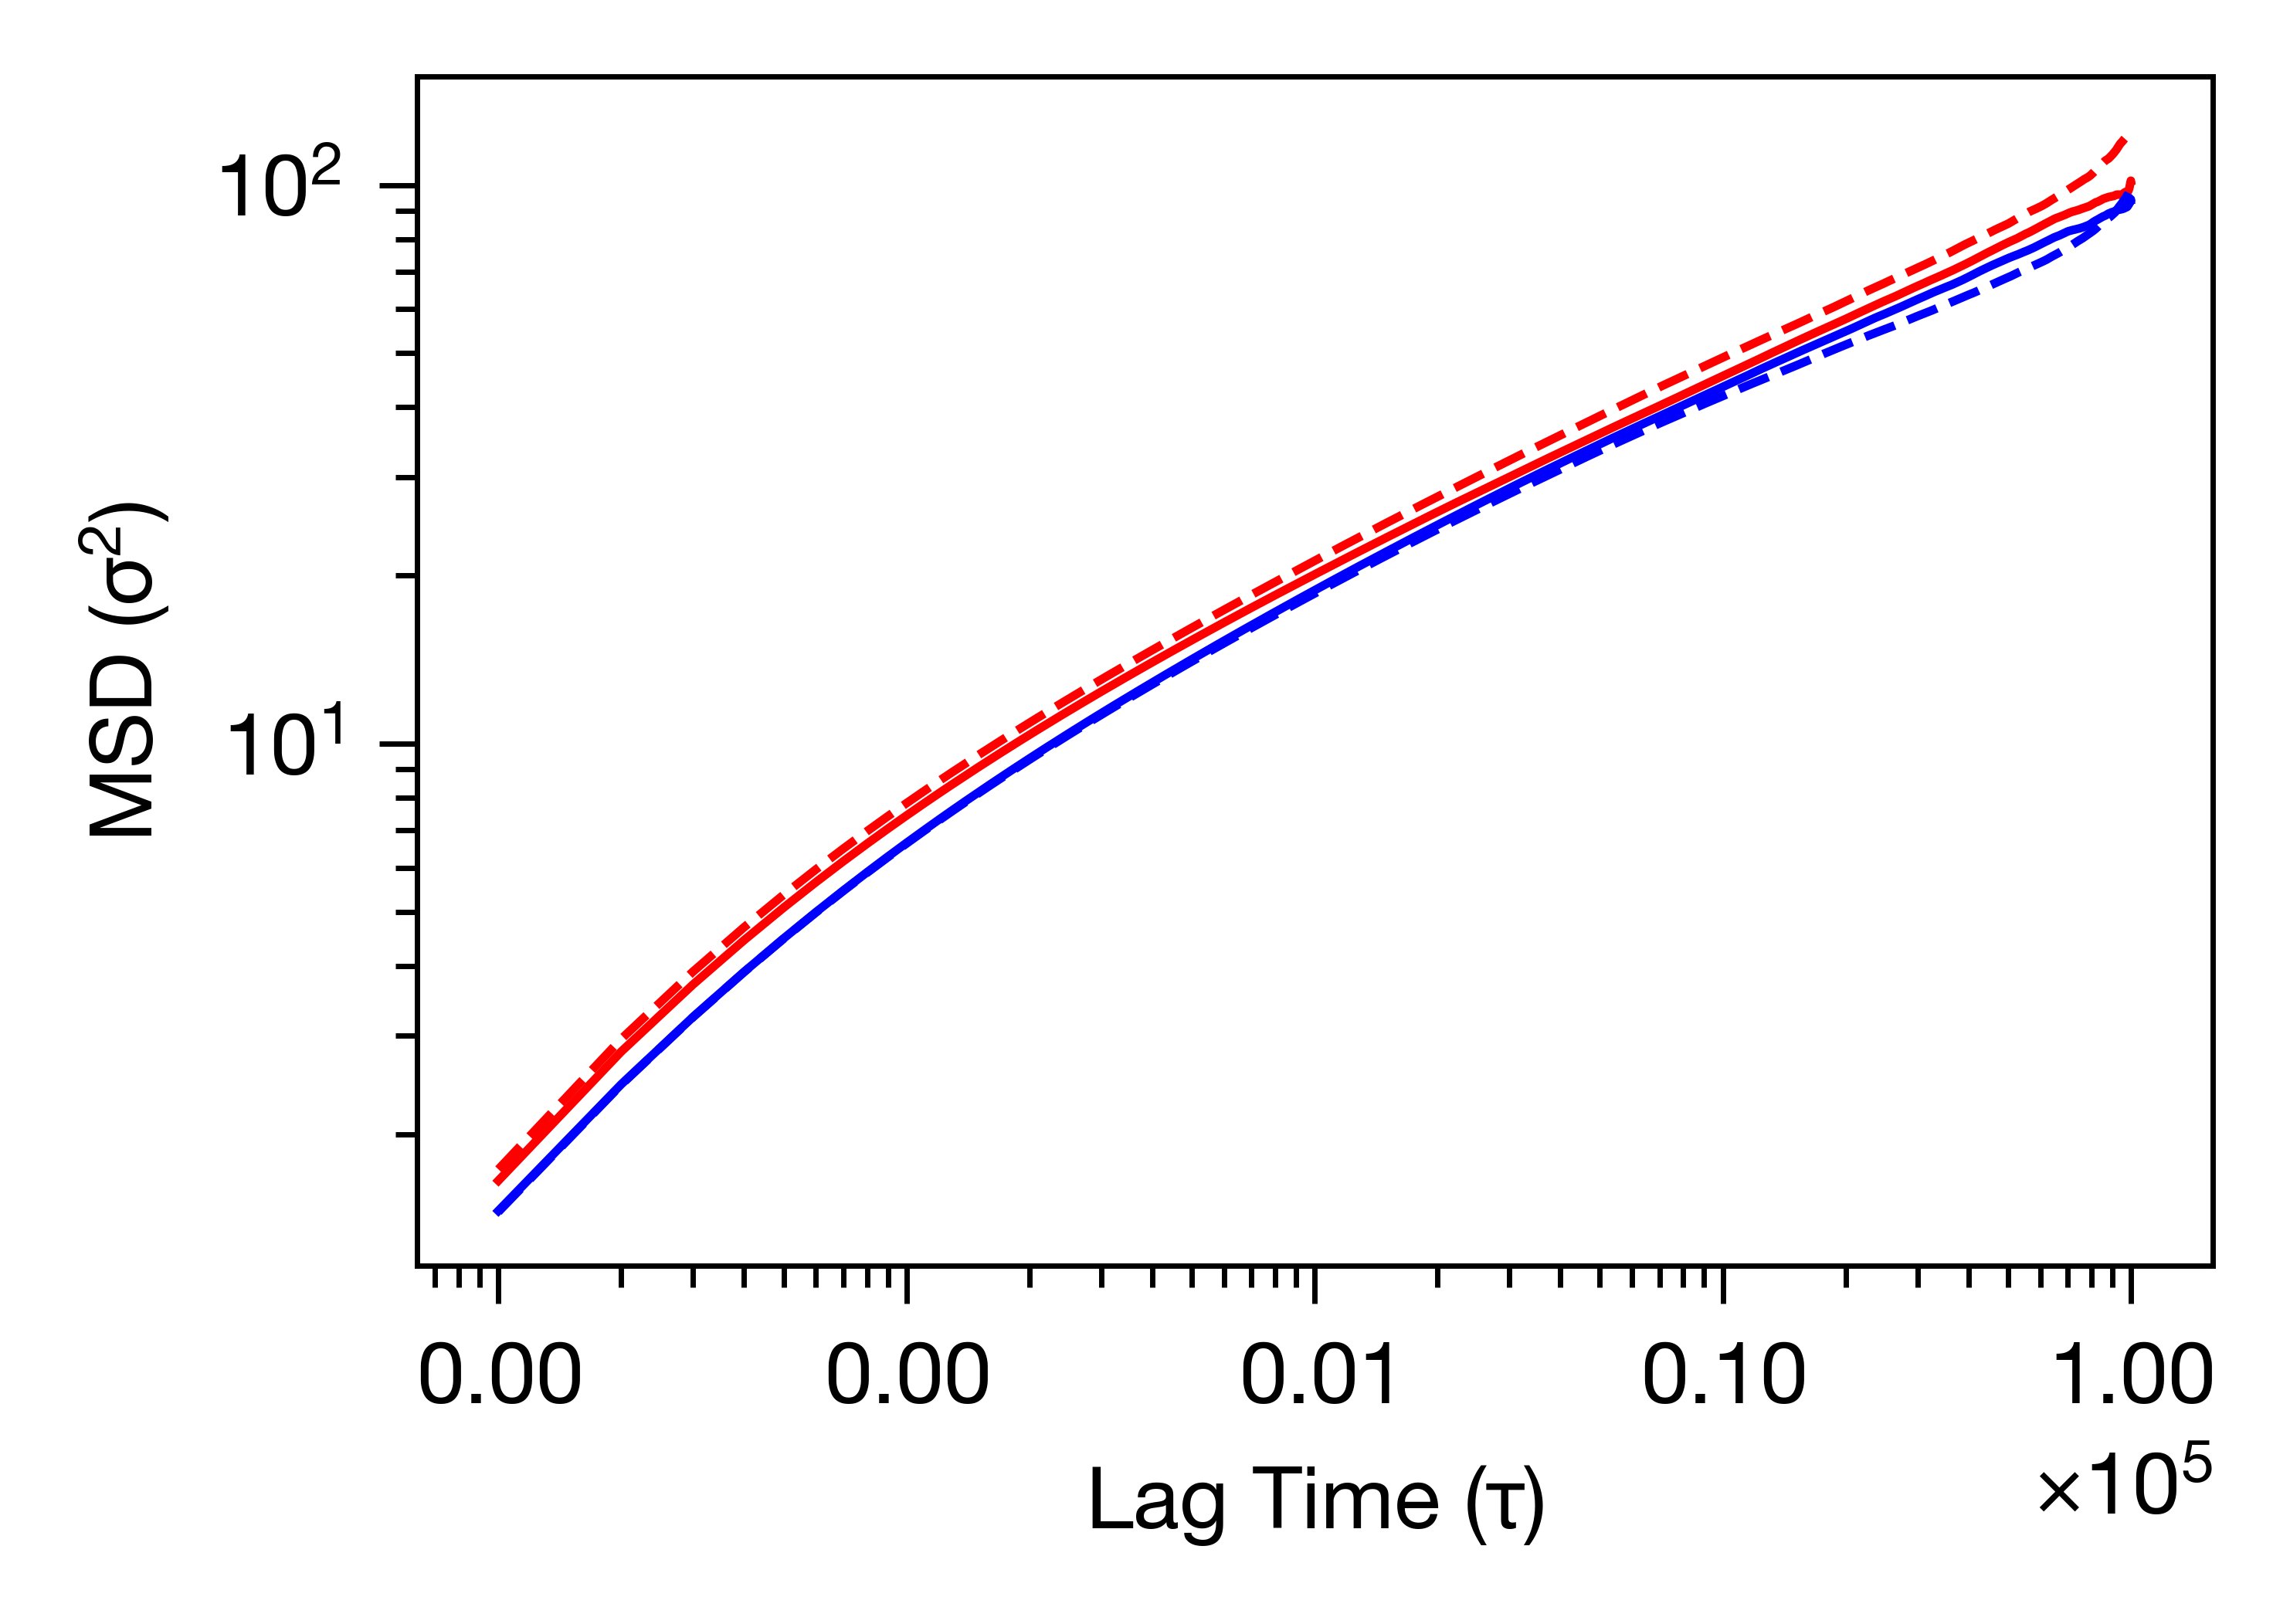

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

ax.loglog(
    lag[1:],
    msd["complete"]["A"][1:],
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["A"][1:],
    "--",
    label="A",
    color="red",
)
ax.loglog(
    lag[1:],
    msd["complete"]["B"][1:],
    label="B",
    color="blue",
)
ax.loglog(
    lag[1:],
    msd["nucleolus"]["B"][1:],
    "--",
    label="B",
    color="blue",
)

ax.set_ylabel(r"MSD ($\sigma^2$)")
ax.set_xlabel(r"Lag Time ($\tau$)")

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

# Apply formatter
ax.xaxis.set_major_formatter(formatter)

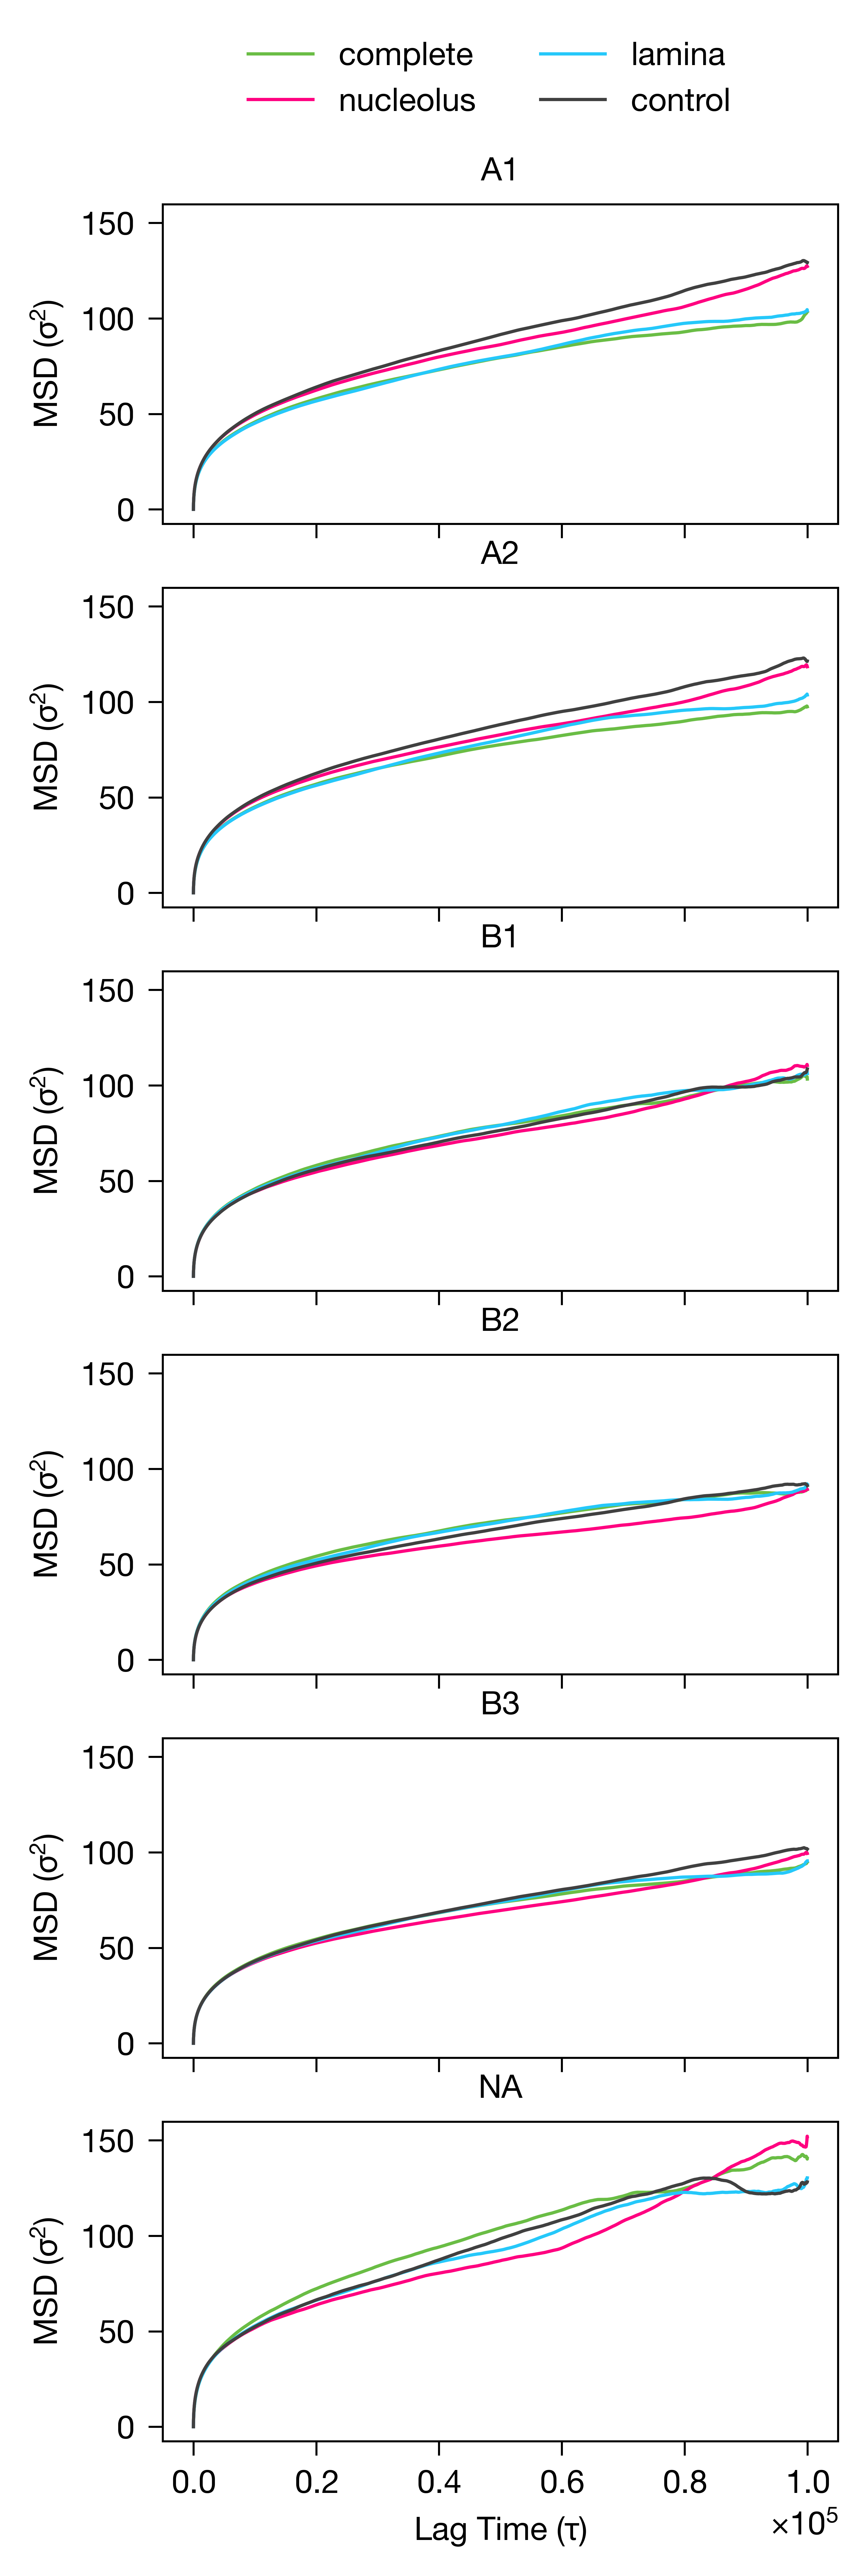

In [14]:
fig, ax = plt.subplots(
    6, 1, figsize=(3, 10), sharex=True, sharey=True
)

lag = np.arange(msd["complete"]["A"].shape[0]) * 1000 * 0.01  # in tau

conditions = ["complete", "nucleolus", "lamina", "control"]

colors = {
    "complete": "#6abd45",
    "nucleolus": "#ff0080",
    "control": "#404040",
    "lamina": "#25C8FA",
    # "isolation": "#FFC083",
}

formatter = mpl.ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))  # Force scientific notation

for i, subcompartment in enumerate(
    ["A1", "A2", "B1", "B2", "B3", "NA"]
):
    for condition in conditions:
        ax[i].plot(
            lag,
            msd[condition][subcompartment],
            label=condition,
            color=colors[condition],
        )

    ax[i].set_title(f"{subcompartment}")
    ax[i].set_ylabel(r"MSD ($\sigma^2$)")
    if i == 5:
        ax[i].set_xlabel(r"Lag Time ($\tau$)")

    ax[i].xaxis.set_major_formatter(formatter)

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.9),
)